### Model preview

This notebook demonstrates how to preview the generated spectrum to compare with the observed data

This is to used before the fitting proceedure to have a flabour f how different parameters are affecting the line profile and what could be some sensible parameter bounds one should use


In [59]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [60]:
SPAMMSFIT_DIR = Path.home() / "SpammsFit" # Path to the local SpammsFit repository.
SPAMMSFIT_SRC = SPAMMSFIT_DIR / "src" # temporarily import the spammsfit source package 
if not SPAMMSFIT_SRC.is_dir():
    raise FileNotFoundError(f"Could not find the SpammsFit source directory: {SPAMMSFIT_SRC}")
if str(SPAMMSFIT_SRC) not in sys.path:
    sys.path.insert(0, str(SPAMMSFIT_SRC))
import spammsfit as spfit
import spammsfit.plotting as spplot

#### Configure SpammsFit to point to the local SPAMMS installation

In [61]:
SPAMMS_DIR = Path.home() / "PhD_stuff" / "SPAMMS" # Change this path to the user's local SPAMMS installation.
config = spfit.SpammsConfig(
    spamms_directory=SPAMMS_DIR,
    spamms_script=SPAMMS_DIR / "spamms.py", #path to the local main spamms.py file
    temporary_directory=SPAMMSFIT_DIR / "examples" / "outputs" / "DE_temp",  #temporary file storage during spamms runs
    results_directory=SPAMMSFIT_DIR / "examples" / "results" / "DE_results", # output folder
    )

#### Load data

We are using an example spectrum of a HeII 4200 profile for a star with $T_{eff}$ = 40000, $M/M_\odot$ = 25, $R/R_\odot$ = 6.5.

Replace your own data and  read-data functions.

In [62]:
#data = np.loadtxt('/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/obs_profiles/noisy_spectra/inc87_vcrit0.83_R149_T197_SN500.txt')
#wavelength, flux = data[:, 0], data[:, 1]

with fits.open('/home/c4011027/SpammsFit/examples/data/zeta_oph_stacked_spectrum.fits') as hdul:
    wavelength = hdul[0].data[0]
    flux = hdul[0].data[1]

mask = (wavelength >= 4000) & (wavelength <= 4300)
wavelength, flux= wavelength[mask], flux[mask]
SNR = 500.0 
flux_uncertainty = np.full_like(flux, 1.0 / SNR)

#### correct for any RV shift. 
For this spectrum, we know the corresponding RV is ~80 km/s

In [63]:
def rv_correct(wavelength, rv):
    c = 299792.458  # km/s
    beta = rv / c
    doppler_factor = np.sqrt((1.0 + beta) / (1.0 - beta))
    return np.asarray(wavelength) / doppler_factor
wavelength = rv_correct(wavelength, rv = 80) 

#save the spectrum -optional
np.savetxt("spectrum.txt", np.column_stack((wavelength, flux)), header="wavelength flux", fmt="%.10f")

In [64]:
# make a spectrum object
spectrum = spfit.Spectrum(wavelength=wavelength, flux=flux,uncertainty=flux_uncertainty)

In [65]:
print(spectrum)
print(f"Number of wavelength points: {wavelength.size}")
print(f"Wavelength range: {wavelength.min():.2f} -- {wavelength.max():.2f} Å")
print(f"Assumed flux uncertainty: {1.0 / SNR:.5f}")

Spectrum(name=None, size=43364, n_lines=0, n_fitting_pixels=0)
Number of wavelength points: 43364
Wavelength range: 3998.93 -- 4298.85 Å
Assumed flux uncertainty: 0.00200


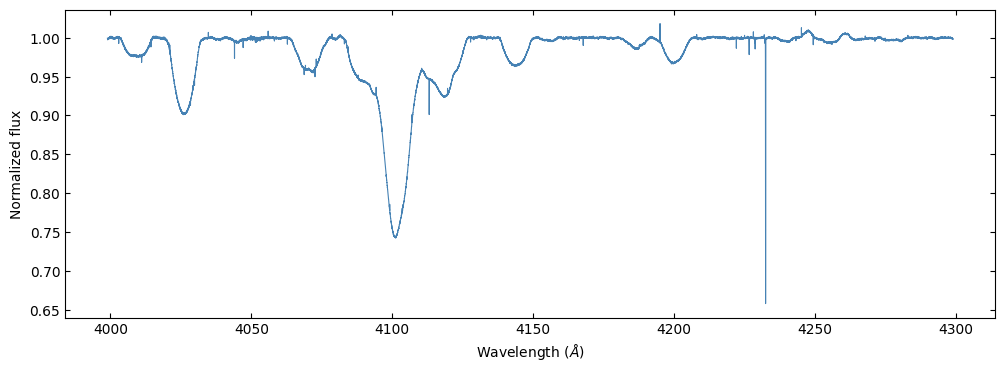

In [66]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(wavelength, flux, color="steelblue", linewidth=0.8)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Normalized flux")
ax.tick_params(direction="in", top=True, right=True)
plt.show()

#### Add and Remove lines for analysis

add_line takes the nmae of the line species that you want to add. The name should be same as used by SPAMMS (i.e. in capital letters )

remove_line only needs the species names for removing a line from the selected linelist.

Overwrite option is to replace an already added line with updated fitting ranges

In [68]:
spectrum.add_line(name="HEII4200", fitting_range=(4192.0, 4209.0), overwrite = True) 
spectrum.add_line(name="HEI4026", fitting_range=(4015.0, 4035.0), overwrite = True)
print("Selected lines:", spectrum.line_names)

Selected lines: ('HEII4200', 'HEI4026')


In [69]:
#spectrum.remove_line("HEI4471")
print("Selected lines after removal:", spectrum.line_names)

Selected lines after removal: ('HEII4200', 'HEI4026')


#### Set the input file and parameter sets for fitting

parameters.fix for setting a parameter to a constant value.

Only the free paramteres will enter the optimization. The parameter bounds should be provided as (lower_bound, upper_bound)

In [145]:
parameters = spfit.ParameterSet(input_file=SPAMMS_DIR / "input.txt")
parameters.fix(teff=33000, r_pole=7, mass=18)
parameters.free(inclination=(10.0, 90.0), v_crit_frac=(0.1, 0.9), sigma_R=(50.0, 300.0), sigma_T=(50.0, 300.0))

In [146]:
print(parameters.summary())
print("Free parameters:", parameters.free_names())
print("Initial vector:", parameters.initial_vector())
print("Bounds:", parameters.continuous_bounds())

SPAMMS input file: /home/c4011027/PhD_stuff/SPAMMS/input.txt
Selected lines: HEI4026
Parameters:
  ntriangles: fixed at 10000
  teff: fixed at 33000.0
  r_pole: fixed at 7.0
  mass: fixed at 18.0
  inclination: free continuous, bounds=(10.0, 90.0)
  v_crit_frac: free continuous, bounds=(0.1, 0.9)
  sigma_R: free continuous, bounds=(50.0, 300.0)
  sigma_T: free continuous, bounds=(50.0, 300.0)
Free parameters: ('inclination', 'v_crit_frac', 'sigma_R', 'sigma_T')
Initial vector: [ 55.    0.6 100.  100. ]
Bounds: ((10.0, 90.0), (0.1, 0.9), (50.0, 300.0), (50.0, 300.0))


#### view models for a parameter set

In [147]:
spamms_fit = spfit.SpammsFit(spectrum=spectrum, parameters=parameters, config=config)

In [155]:
preview_parameters = {"inclination": 55, "v_crit_frac": 0.6, "sigma_R":200.0, "sigma_T": 250.0}
preview = spamms_fit.preview_model(**preview_parameters)

In [156]:
print(preview.summary())
print("\nParameters used:")
print(preview.parameters)

Method: SPAMMS model preview
Chi-square: 554495.307206
Reduced chi-square: 102.570349
Log likelihood: -248619.263933
Model evaluations: 1
Runtime: 9.465 seconds
Best parameters:
  ntriangles: 10000 (fixed)
  teff: 33000.0 (fixed)
  r_pole: 7.0 (fixed)
  mass: 18.0 (fixed)
  inclination: 55.0 (fixed)
  v_crit_frac: 0.6 (fixed)
  sigma_R: 200.0 (fixed)
  sigma_T: 250.0 (fixed)
Chi-square by line:
  HEII4200: 85820.021091
  HEI4026: 468675.286115

Parameters used:
{'ntriangles': 10000, 'teff': 33000.0, 'r_pole': 7.0, 'mass': 18.0, 'inclination': 55.0, 'v_crit_frac': 0.6, 'sigma_R': 200.0, 'sigma_T': 250.0}


In [ ]:
import spammsfit.plotting as spplot
figure, axes = spplot.plot_fit(preview, show_native_model=False, figsize=(10, 4), show=True)